# Overview

In this notebook you will compare the performance of a standard network to a convolutional network on a data set of images. 

Then you will permute the data and compare how well each type of network performs on the permuted data.

# Experiment with the MNIST data set

MNIST is a data set composed of hand-written digits that have been pre-processed to make the problem easier.  It's considered a 'toy' dataset now, but it was the original dataset that a lot of the earlier CNN work was done on.  The images are originally from scans of zip-codes on letters, and were provided by the US Post Office (see https://en.wikipedia.org/wiki/MNIST_database for more details).

It's recommended that you run this code in the CS63env on our servers, or run it on Google Colab; trying to train models like this on a personal laptop is typically very slow.

In [1]:
#NOTE: if running on google colab, uncomment the following line!
#%pip install aitk --quiet

In [1]:
import numpy as np
from collections import Counter
from time import sleep
from aitk.utils import gallery, array_to_image
from aitk.networks import SequentialNetwork, Flatten, Dense, InputLayer, Conv2D, MaxPooling2D
import tensorflow
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
# NOTE: TensorFlow may generate some warnings here;
# usually it's just status info and can be safely ignored

2026-03-27 14:21:29.575874: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-27 14:21:30.721822: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774635691.104052  192863 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774635691.218382  192863 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774635692.164433  192863 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

# Get the data
* Download the data
* Explore what you have

In [2]:
(train_x, train_y), (test_x, test_y) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
type(train_x)

numpy.ndarray

In [4]:
train_x.shape

(60000, 28, 28)

In [5]:
test_x.shape

(10000, 28, 28)

### Examining images
Let's look at a 'raw' vector, and then interpret it as them as images:

In [6]:
test_x[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

In [7]:
images = [array_to_image(train_x[i]) for i in range(20)]

In [8]:
gallery(images)

0,1,2,3,4
5,6,7,8,9
10,11,12,13,14
15,16,17,18,19


In [9]:
train_y[:20]

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4, 3, 5, 3, 6, 1, 7, 2, 8, 6, 9],
      dtype=uint8)

# Prepare the data for the network
* You may need to normalize the inputs so that they are in the range [0,1].
* You may need to convert the targets so that they are represented as 'one-hot' vectors when you are doing categorization (this means a vector with the number of elements equal to the number of categories, where the $i$'th element being 1 means it belongs to the $i$'th class).

###  Normalizing the input data

Start by finding the minimum value and the maximum value within your data set.

In [10]:
min_input = train_x.min()
max_input = train_x.max()
print(f"range of input values is: [{min_input}, {max_input}]")

range of input values is: [0, 255]


The formula for normalizing your data is:

`(data - min_input)/(max_input - min_input)`

For most image data the min_input is 0 and the max_input is 255, as is the case here.  This simplifies the equation to:

`data/255`

_NOTE:_ be cautious, since if you do this on a per-element basis, you can have problems with e.g. the corners of the images always having a value of 0; for images like this, we want to normalize using the same range for every element, but for other types of data other strategies may be more appropriate


In [11]:
train_x_normalized = train_x/255
test_x_normalized = test_x/255

### Data sent into a Conv2D layer must have a depth
* This may require you to do a reshape command.
* For these black and white images there is only one channel of information.
* For color images there are typically 3 channels (Red, Green, Blue)

In [12]:
(n, w, h) = train_x_normalized.shape
(nt, w, h) = test_x_normalized.shape
train_x_normalized = train_x_normalized.reshape(n,w,h,1)
test_x_normalized = test_x_normalized.reshape(nt,w,h,1)

### Target data

When doing a classification task we would typically convert the output into one-hot vectors. For some data sets you may not know how many classes there are.  You can put the training data into a set to find out how many unique classifications you have.

In [13]:
num_categories = len(set(train_y))
print(f"number of labels: {num_categories}")

number of labels: 10


Then you can use the number of categories to produce one-hot vectors using `to_categorical`.

In [14]:
train_y_category = to_categorical(train_y, num_categories)

In [15]:
test_y_category = to_categorical(test_y, num_categories)

In [16]:
print(f"raw label: {train_y[0]}")
print(f"one-hot vector: {train_y_category[0]}")

raw label: 5
one-hot vector: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


# Construct a Multi-Layer Perceptron Model using Tensorflow
Now we'll construct a basic MLP, i.e. a fully-connected feed-forward network.  This is similar to the network we build and trained by hand, but now we're using a library to do the work for us.  In this case, not only does it save us time on implementing things from scratch, but it also lets us use the low-level GPU-optimized code that will make the runtime much faster than it would be if we did things from scratch.

To start with, we'll use a single hidden layer with 256 nodes and the logistic-sigmoid activation function.  Note that this library uses `Dense` to refer to a fully-connected layer, and that it requires us to `Flatten` our inputs before passing our image-shaped inputs into one.

The output layer will have 10 units, one per class label.

Feel free to play around with this network architecture if you like; does adding more nodes to the hidden layer help or hurt?  What about more layers?

-----

Notice that in the output layer we are using an activation function called **softmax**.  This will output a pseudo-probability and is typically used in classification problems like the one we are trying to solve.  It should be paired with the loss function called **categorical_crossentropy**.

Also, this will produce some output that may look like 'warnings', but it's actually just information being produced by tensorflow.  It's *possible* that there might be actual issues in there, but more often than not you can ignore those messages safely.

In [17]:
# Create a feed-forward network[
(number, width, height, channels) = train_x_normalized.shape
net = SequentialNetwork(
    # start with an input layer
    InputLayer([width,height,channels], name="input"),
    # then flatten
    Flatten(name="flatten"),
    # now a hidden layer with 256 nodes
    Dense(256, activation='sigmoid', name='hidden_1'),
    # and finally an output layer
    Dense(10, activation='softmax', name='output')
)

# this next line prints out a description of the network we've built
net.summary()

I0000 00:00:1774635881.670373  192863 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9711 MB memory:  -> device: 0, name: NVIDIA RTX A2000 12GB, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "SequentialNetwork"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

## Compile the model

Keras uses the method 'compile' to indicate that the network architecture is fully specified, and we're ready to set things up to actually do processing.

The 'optimizer' is what variant on gradient descent we'll be using, the 'loss' function is what defines the gradient, and the 'metrics' are what sort of scores we want it to report during the training process.  The `SGD` optimizer is a version of stochastic gradient descent, very similar to the one we implemented ourselves.

For our XOR networks we defined loss as sum-squared error.  However, for categorical data like handwritten digits it is better to use a different loss function called *categorical_crossentropy* (again, this is the loss function that is designed to be paired with the *softmax* output-layer activation function).  This interprets the outputs as representing pseudo-probabilities and forces them to sum to 1.0.  Thus the output from the network will reflect how likely it considers a particular input to be a member of one of the output categories.

In [18]:
net.compile(optimizer="SGD", loss="categorical_crossentropy",
                   metrics=['accuracy'])

The loop below shows you how the network performs on 10 sample images.  When you run this cell **prior** to training the output layer (at the top) has no clear winning categories before learning has occurred. However, if you re-run this cell **after** training you'll see that the network has correctly learned the classification for almost all of the images.

In [21]:
for i in range(10,20):
    net.propagate(test_x_normalized[i])
    net.display(test_x_normalized[i])
    sleep(1.0)

## Train the model

In [20]:
history = net.fit(train_x_normalized, # training examples
                  train_y_category,   # training labels
                  verbose=1,          # verbose output
                  validation_data=(test_x_normalized,  # validation examples
                                   test_y_category),   # validation labels
                  epochs=20)  # number of times to loop through the training set

Epoch 20/20 accuracy: 0.9194666743278503 - loss: 0.27995938062667847 - val_accuracy: 0.9221000075340271 - val_loss: 0.27177661657333374


## Examine the results
Check which inputs the network is getting wrong. Recall that there are 10 thousand test images.



In [22]:
from numpy import argmax
outputs = net.predict(test_x_normalized)
answers = [argmax(output) for output in outputs]
targets = [argmax(target) for target in test_y_category]

/home/meeden/Envs/CS63env/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(10000, 28, 28, 1))
  warnings.warn(msg)


In [23]:
incorrect = [i for i in range(len(answers)) if answers[i] != targets[i]]
missed_target = [targets[i] for i in incorrect]
wrong_answer = [answers[i] for i in incorrect]
print("Number of incorrectly categorized images", len(missed_target))

Number of incorrectly categorized images 779


We can use the `Counter` class from the `collections` library to find out which target is most commonly missed. 

In [24]:
t_ctr = Counter(missed_target)
t_ctr.most_common()

[(np.int64(8), 123),
 (np.int64(9), 115),
 (np.int64(5), 109),
 (np.int64(2), 109),
 (np.int64(3), 94),
 (np.int64(7), 77),
 (np.int64(4), 56),
 (np.int64(6), 50),
 (np.int64(1), 26),
 (np.int64(0), 20)]

And we can find out which wrong answer is most commonly given.

In [25]:
a_ctr = Counter(wrong_answer)
a_ctr.most_common()

[(np.int64(8), 99),
 (np.int64(3), 92),
 (np.int64(4), 90),
 (np.int64(5), 88),
 (np.int64(9), 84),
 (np.int64(6), 76),
 (np.int64(7), 73),
 (np.int64(2), 69),
 (np.int64(0), 66),
 (np.int64(1), 42)]

This standard network is likely making a lot of mistakes on the validation data. Let's see if a convolutional network can obtain better results. 

# Construct a Convolutional Network model

Now we'll construct a CNN to see how it compares to the MLP networks we used previously.

This is just one possible configuration of layers to learn the MNIST data set.  Feel free to experiment with the number of filters, the filter size, and the layers themselves.

In [26]:
# Create a feed-forward network
conv_net = SequentialNetwork(
    InputLayer([28,28,1], name="input"),
    # we'll start with a convolutional layer with 16 filter kernels, each 3x3
    Conv2D(filters=16, kernel_size=(3,3), name='conv1'),
    # next, a 2x2 pooling layer
    MaxPooling2D(pool_size=(2,2),name='pool1'),
    # then another convolutional layer, this time with 32 filters
    Conv2D(filters=32, kernel_size=(3,3), name='conv2'),
    # a second pooling layer
    MaxPooling2D(pool_size=(2,2),name='pool2'),
    # for the 'top' we'll flatten and then have one dense ReLU layer
    Flatten(name="flatten"),
    Dense(256, activation='relu', name='hidden'),
    # and finally our output layer
    Dense(10, activation='softmax', name='output')
)

conv_net.summary()

Model: "SequentialNetwork"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden (Dense)                  │ (None, 256)            │       205,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,426 (829.79 KB)

 Trainable params: 212,426 (829.79 KB)

 Non-trainable params: 0 (0.00 B)

## Compile the model

This time, let's try the 'adam' optimizer; it's a version of SGD that uses ADAptive Momentum (hence the name), which means it's a bit less vulnerable to badly chosen hyperparameters like learning rate (here we'll leave things at their defaults, but you can specify lots of hyperparameters if you want, see https://keras.io/api/optimizers/adam/).

In [27]:
conv_net.compile(optimizer="adam", loss="categorical_crossentropy",
                   metrics=['accuracy'])

Again, this cell is more interesting **after** training, as you'll see that the network has correctly learned the classification for almost all of the images.

In [30]:
for i in range(10,20):
    conv_net.propagate(test_x_normalized[i])
    conv_net.display(test_x_normalized[i])
    sleep(1.0)

## Train the model

In [42]:
history = conv_net.fit(train_x_normalized, # training examples
                  train_y_category,   # training labels
                  verbose=1,          # verbose output
                  validation_data=(test_x_normalized,  # validation examples
                                   test_y_category),   # validation labels
                  epochs=5)  # number of times to loop through the training set

Epoch 5/5 


## Inspect the feature maps

We can ask the network to propagate to specific layers and inspect the representations created there to try to understand how it has solved the problem.

Using one test image, find out what the maximum value is so that you can set up the color map properly. If you see a large red box in one of the visualized channels below, then use the image number for that test image to correct the color map.

In [43]:
from math import ceil
for layer in ["conv1", "pool1"]:
    data = [conv_net.propagate_to(test_x_normalized[49], layer, channel=channel)
            for channel in range(8)]
    largest = max([sublist.max() for sublist in data])
    conv_net.set_config_layer(layer, colormap=("gray", 0, ceil(largest)))

/home/meeden/Envs/CS63env/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(1, 28, 28, 1))
  warnings.warn(msg)


Check out 10 different test images to see how each channel is representing them. Each set of images will be displayed for 1 second. You can lengthen this time by updating the parameter to the **sleep** call.

This first block of code propagates to the convolution layer.

channel0,channel1,channel2,channel3,channel4,channel5,channel6,channel7,channel8

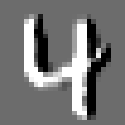
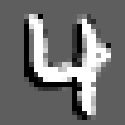
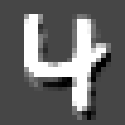
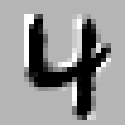
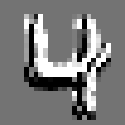
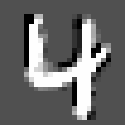
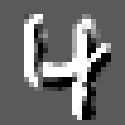
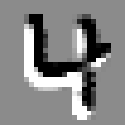

In [44]:
for test_case in range(40,50):
    c_images = [conv_net.propagate_to(test_x_normalized[test_case], "conv1", "image", channel=channel)
                for channel in range(8)]
    c_bigger = [image.resize((125,125),resample=0) for image in c_images]
    original = test_x_normalized[test_case]
    gallery([original] + c_bigger, labels="channel{index}", gallery_shape=(9,1))
    sleep(1.0)

This next block of code propagates to the pooling layer. Notice that the images are becoming less detailed due to the pooling of information from the previous layer.

channel0,channel1,channel2,channel3,channel4,channel5,channel6,channel7,channel8

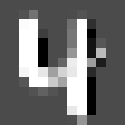
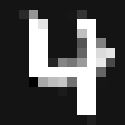
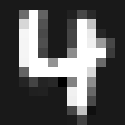
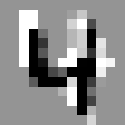
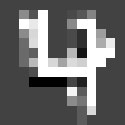
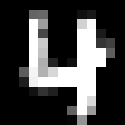
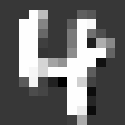
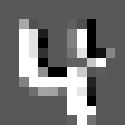

In [45]:
for test_case in range(40,50):
    p_images = [conv_net.propagate_to(test_x_normalized[test_case], "pool1", "image", channel=channel)
                for channel in range(8)]
    p_bigger = [image.resize((125,125),resample=0) for image in p_images]
    original = test_x_normalized[test_case]
    gallery([original] + p_bigger, labels="channel{index}", gallery_shape=(9,1))
    sleep(1.0)

## Examine the results
Check which inputs the network is getting wrong. Recall that there are 10 thousand test images.

In [46]:
from numpy import argmax
outputs = conv_net.predict(test_x_normalized)
answers = [argmax(output) for output in outputs]
targets = [argmax(target) for target in test_y_category]

/home/meeden/Envs/CS63env/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(10000, 28, 28, 1))
  warnings.warn(msg)


In [47]:
incorrect = [i for i in range(len(answers)) if answers[i] != targets[i]]
missed_target = [targets[i] for i in incorrect]
wrong_answer = [answers[i] for i in incorrect]
print("Number of incorrectly categorized images", len(missed_target))

Number of incorrectly categorized images 117


We can use the `Counter` class from the `collections` library to find out which target is most commonly missed and which wrong answer is most commonly given.

In [48]:
from collections import Counter

In [49]:
t_ctr = Counter(missed_target)
t_ctr.most_common()

[(np.int64(6), 19),
 (np.int64(4), 15),
 (np.int64(2), 14),
 (np.int64(8), 14),
 (np.int64(7), 14),
 (np.int64(9), 11),
 (np.int64(3), 9),
 (np.int64(5), 8),
 (np.int64(1), 7),
 (np.int64(0), 6)]

In [50]:
a_ctr = Counter(wrong_answer)
a_ctr.most_common()

[(np.int64(9), 29),
 (np.int64(8), 22),
 (np.int64(5), 21),
 (np.int64(7), 11),
 (np.int64(3), 9),
 (np.int64(0), 6),
 (np.int64(4), 6),
 (np.int64(6), 5),
 (np.int64(2), 5),
 (np.int64(1), 3)]

### Confusion Matrix
We can also build a **Confusion Matrix** to see what mistakes are being made.

This is a matrix (or 2D array) where the 'true' labels are arranged on the rows, and the 'predictions' are arranged on the columns (or vice-versa if you give the argument in the other order).  The count in a given cell is how many times that prediction-target combination occurred (i.e. how many times that prediction was given when that target _should_ have been given).

For more details on the library functions being used here, see:

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html

In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(targets, answers)
cm

array([[ 974,    0,    1,    0,    0,    1,    1,    0,    1,    2],
       [   0, 1128,    0,    1,    1,    1,    0,    1,    3,    0],
       [   0,    0, 1018,    0,    2,    0,    1,    9,    2,    0],
       [   0,    0,    1, 1001,    0,    4,    0,    0,    4,    0],
       [   0,    1,    0,    0,  967,    0,    1,    0,    2,   11],
       [   0,    0,    0,    6,    0,  884,    1,    0,    1,    0],
       [   5,    2,    0,    0,    1,    6,  939,    0,    4,    1],
       [   0,    0,    1,    1,    0,    1,    0, 1014,    1,   10],
       [   1,    0,    2,    1,    0,    3,    1,    1,  960,    5],
       [   0,    0,    0,    0,    2,    5,    0,    0,    4,  998]])

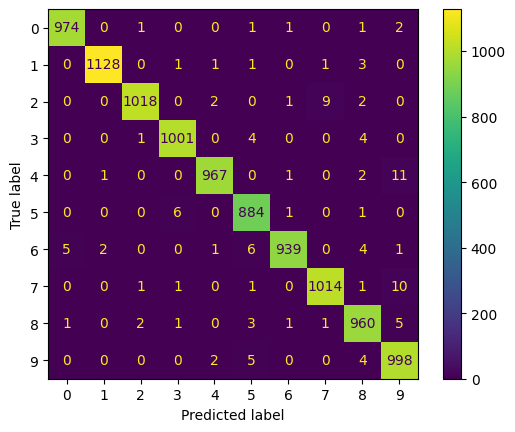

In [52]:
# there's also options for pretter formatting; this one uses a color-based heat-map by default
# there's a bunch of options to control the display in more detail if you want them
cm_plt = ConfusionMatrixDisplay(cm)
cm_plt.plot()

In [53]:
images = [array_to_image(test_x[index]) for index in incorrect]
gallery(images, labels=wrong_answer)

8,9,0,8,4,3,8,5,5,6,2
7,8,6,7,9,5,9,7,5,9,5
6,8,5,2,4,9,5,9,7,9,9
5,8,7,3,9,4,9,7,3,9,0
9,1,8,5,3,9,5,4,3,1,8
8,9,5,0,8,2,5,5,9,8,5
0,9,0,9,8,5,9,8,8,3,9
8,7,4,9,3,3,7,7,8,5,9
8,0,7,9,8,9,9,9,3,8,8
5,5,5,5,9,2,8,4,6,9,8
9,5,9,2,7,6,1,,,,


## ** <span style="color:red">TODO: Interpretation</span>


Notice the patterns in the confusion matrix, and think about whether they make sense.  

You can look at either the rows or the columns in the confusion matrix, and they tell you slightly different things; one way is "when the network predicts X, what is the most likely 'true' answer?"  The other way is, "if the true answer is Y, what predictions are the most likely?"

Sometimes things are fairly symmetric, but not always, so it's worth looking at both.

For example, when I ran it I found that the number 9 tended to be confused with 4, 7, and 8; the number 7 tends to be confused with 2 and 9.

Is this reasonable?  Is the pattern of mistakes the same if you re-train the network?

Also note that based on the visualization of wrong answers, some of the 'mistake' examples may look pretty silly to us, but others might be ambiguous even to a human (e.g. due to a bad scan).  How many of these errors are 'reasonable'?  Is it realistic to expect the network to do better than this?

** analysis **
We found that when the 4 or 7 are classified as 9 often, and 2 as 7 is also relatively common. 1 and 2 were pretty stable -- they were not commonly misclassified as another number. Retraining the model produced a similar result. Looking at the images that the model miscorrectly, we realized that it was easy for humans to misclassify the images. Therefore, the mistakes look pretty reasonable. 

## ** <span style="color:red">TODO: Compare Standard to Convolutional Network</span>

Which network achieved better accuracy on the validation data? Why does this make sense?

The CNN produced better accuracy: the standard one produced 91.94666743278503 percentage while the CNN produced 98.8 (approximately). This makes sense because of the CNN's unique ability to understand 2D features. 

# Permuting the data

These MNIST images have *spatial* structure, meaning that the location of a pixel in the image matters. 
To show how this works, we'll create a copy of the MNIST data set where we re-order the features, and then see what difference it makes.

First, let's try out Numpy's `permutation`:

In [54]:
# we'll create an RNG object, then generate a permutation of the desired length
rng = np.random.default_rng(seed=33)
length = 10
permutation = rng.permutation(np.arange(length))
# let's see what we got
for a, b in zip(np.arange(length), permutation):
    print(f"{a:3} -> {b:3}")

  0 ->   0
  1 ->   6
  2 ->   8
  3 ->   1
  4 ->   4
  5 ->   3
  6 ->   5
  7 ->   9
  8 ->   2
  9 ->   7


### Apply a permutation to a vector
Now let's make a permuted copy of our data set.  We'll first flatten the vectors, then we'll apply our permutation, and finally we'll re-shape things back to the original dimensions

In [55]:
# get the shapes
(n, w, h) = train_x.shape
(nt, wt, ht) = test_x.shape
assert(w == wt and h == ht) # make sure train and test have same image size
size = w * h # compute overall size

# flatten
train_x_flat = np.reshape(train_x, (n, size))
test_x_flat = np.reshape(test_x, (nt, size))

# deep copies (mostly to get the size right)
train_x_permuted = train_x_flat.copy()
test_x_permuted = test_x_flat.copy()

# now we'll do the actual permutation
permutation = rng.permutation(np.arange(size))
for a, b in zip(np.arange(size), permutation):
    train_x_permuted[:,a] = train_x_flat[:,b]
    test_x_permuted[:,a] = test_x_flat[:,b]

# un-flatten
train_x_permuted = np.reshape(train_x_permuted, (n, w, h))
test_x_permuted = np.reshape(test_x_permuted, (nt, w, h))

## Let's see what happened
We'll use the same code from earlier to display the vectors as images; first, we'll re-display the 'original' images, then we'll display the corresponding 'permuted' images.

In [56]:
print("Original:")
images = [array_to_image(train_x[i]) for i in range(20)]
gallery(images)

0,1,2,3,4
5,6,7,8,9
10,11,12,13,14
15,16,17,18,19


In [57]:
print("Permuted:")
images2 = [array_to_image(train_x_permuted[i]) for i in range(20)]
gallery(images2)

0,1,2,3,4
5,6,7,8,9
10,11,12,13,14
15,16,17,18,19


# Prepare the data for the network
* Normalize the inputs so that they are in the range [0,1].
* Reshape the input.

In [70]:
train_x_permuted_normalized = train_x_permuted/255
test_x_permuted_normalized = test_x_permuted/255

In [71]:
train_x_permuted_normalized = train_x_permuted_normalized.reshape(n,w,h,1)
test_x_permuted_normalized = test_x_permuted_normalized.reshape(nt,w,h,1)

## ** <span style="color:red">TODO: Try a standard network on the permuted data</span>

Try a standard network on the _randomly permuted_ version of the data set, then describe what you saw here.  

## Create the model

In [72]:
# Create a feed-forward network[
(number, width, height, channels) = train_x_permuted_normalized.shape
net = SequentialNetwork(
    # start with an input layer
    InputLayer([width,height,channels], name="input"),
    # then flatten
    Flatten(name="flatten"),
    # now a hidden layer with 256 nodes
    Dense(256, activation='sigmoid', name='hidden_1'),
    # and finally an output layer
    Dense(10, activation='softmax', name='output')
)

# this next line prints out a description of the network we've built
net.summary()

Model: "SequentialNetwork"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

## Compile the model

In [73]:
net.compile(optimizer="SGD", loss="categorical_crossentropy",
                   metrics=['accuracy'])

## Train the model

In [74]:
history = net.fit(train_x_permuted_normalized, # training examples
                  train_y_category,   # training labels
                  verbose=1,          # verbose output
                  validation_data=(test_x_permuted_normalized,  # validation examples
                                   test_y_category),   # validation labels
                  epochs=20)  # number of times to loop through the training set

Epoch 20/20 accuracy: 0.9192666411399841 - loss: 0.280712366104126 - val_accuracy: 0.9230999946594238 - val_loss: 0.27158424258232117


## Compare the results to the non-permuted version

Did the network handle the permuted data any differently than the original data? Why do you think the results you got make sense?

The non-permuted version: Epoch 20/20 accuracy: 0.9194666743278503 - loss: 0.27995938062667847 - val_accuracy: 0.9221000075340271 - val_loss: 0.27177661657333374
The accuracy does not really change.

## ** <span style="color:red">TODO: Try a convolutional network on the permuted data</span>

Try a convolutional network on the _randomly permuted_ version of the data set, then describe what you saw here. 

## Create the model

In [75]:
# Create a feed-forward network
conv_net = SequentialNetwork(
    InputLayer([28,28,1], name="input"),
    # we'll start with a convolutional layer with 16 filter kernels, each 3x3
    Conv2D(filters=16, kernel_size=(3,3), name='conv1'),
    # next, a 2x2 pooling layer
    MaxPooling2D(pool_size=(2,2),name='pool1'),
    # then another convolutional layer, this time with 32 filters
    Conv2D(filters=32, kernel_size=(3,3), name='conv2'),
    # a second pooling layer
    MaxPooling2D(pool_size=(2,2),name='pool2'),
    # for the 'top' we'll flatten and then have one dense ReLU layer
    Flatten(name="flatten"),
    Dense(256, activation='relu', name='hidden'),
    # and finally our output layer
    Dense(10, activation='softmax', name='output')
)

conv_net.summary()

Model: "SequentialNetwork"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden (Dense)                  │ (None, 256)            │       205,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,426 (829.79 KB)

 Trainable params: 212,426 (829.79 KB)

 Non-trainable params: 0 (0.00 B)

## Compile the model

In [76]:
conv_net.compile(optimizer="adam", loss="categorical_crossentropy",
                   metrics=['accuracy'])

In [77]:
for i in range(10,20):
    conv_net.propagate(test_x_permuted_normalized[i])
    conv_net.display(test_x_permuted_normalized[i])
    sleep(1.0)

## Train the model

In [78]:
history = conv_net.fit(train_x_permuted_normalized, # training examples
                  train_y_category,   # training labels
                  verbose=1,          # verbose output
                  validation_data=(test_x_permuted_normalized,  # validation examples
                                   test_y_category),   # validation labels
                  epochs=5)  # number of times to loop through the training set

Epoch 5/5 accuracy: 0.9920666813850403 - loss: 0.024554327130317688 - val_accuracy: 0.9693999886512756 - val_loss: 0.12482862919569016


## Compare the results to the non-permuted version

Did the CNN handle the permuted data any differently?  Why do you think the results you got make sense?

The validation loss became larger after using the permuted data (from around 0.04 to 0.13). This shows that the models is losing its power to generalize well to new dataset, which means the data is getting less accurate. 